## Compiling Analysese for Culture Work

Jata Culture
 - fixed
 - live

Alex Culture 
 - fixed
 - live
 
Beads ?



## Utilities


In [2]:

from pathlib import Path
import pandas as pd

def combine_csvs_with_filename(directory):
    """
    Combine all CSV files in a directory into one DataFrame.
    Adds a 'FileName' column containing the source filename.
    """
    dfs = []

    for file in Path(directory).glob("*.csv"):
        df = pd.read_csv(file)
        df["FileName"] = file.name
        dfs.append(df)

    if not dfs:
        return pd.DataFrame()

    return pd.concat(dfs, ignore_index=True)

In [3]:
def filter_class(class_name,master_df, alpha):
    """
    Return rows where any column beginning with 'class_name'
    has a value greater than alpha.
    """
    class_cols = [
        col for col in master_df.columns
        if str(col).startswith(class_name)
    ]

    if not class_cols:
        raise ValueError(f"No {class_name} columns found in master_df.")

    mask = (
        master_df[class_cols]
        .apply(lambda col: col > alpha)
        .any(axis=1)
    )

    return master_df.loc[mask].copy()

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest


def plot_single_runtime_cdf(df, title ="KS Test Against Uniformity"):
    data = df["RunTime"].dropna().to_numpy()

    if len(data) == 0:
        raise ValueError("The DataFrame contains no valid RunTime values.")

    if data.max() == data.min():
        raise ValueError("RunTime values must not all be identical.")

    # Scale data to [0, 1]
    scaled = (data - data.min()) / (data.max() - data.min())

    # Empirical CDF
    x = np.sort(scaled)
    n = len(x)
    ecdf = np.arange(1, n + 1) / n

    # Theoretical uniform CDF
    theoretical_x = np.linspace(0, 1, 1000)
    theoretical_cdf = theoretical_x

    # KS test
    ks_stat, p_value = kstest(scaled, "uniform")

    print(f"KS statistic: {ks_stat:.3f}")
    print(f"p-value: {p_value:.3g}")

    # Plot
    plt.figure(figsize=(7, 7))

    plt.step(
        x,
        ecdf,
        where="post",
        label="Observed ECDF"
    )

    plt.plot(
        theoretical_x,
        theoretical_cdf,
        linestyle="--",
        label="Uniform CDF"
    )

    plt.xlabel("Scaled Runtime")
    plt.ylabel("Cumulative Density")
    plt.title(
        f"{title}\n"
        f"D={ks_stat:.3f}, p={p_value:.3g}"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

    return ks_stat, p_value

In [35]:
def plot_multi_runtime_cdf(df, ax, label):
    data = df["RunTime"].dropna().to_numpy()

    scaled = (data - data.min()) / (data.max() - data.min())

    x = np.sort(scaled)
    n = len(x)
    ecdf = np.arange(1, n + 1) / n

    theoretical_x = np.linspace(0, 1, 1000)
    ks_stat, p_value = kstest(scaled, "uniform")

    ax.step(
        x, ecdf,
        where="post",
        label="Observed ECDF"
    )

    ax.plot(
        theoretical_x,
        theoretical_x,
        linestyle="--",
        label="Uniform CDF"
    )

    ax.set_xlabel("Scaled Runtime")
    ax.set_ylabel("Cumulative Density")
    ax.set_title(
        f"{label}\nD={ks_stat:.3f}, p={p_value:.3g}"
    )
    ax.legend()

    return ks_stat, p_value

## Jata Culture

In [49]:
jatalive_df = combine_csvs_with_filename("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/dilExp/jataHighV/hablab_jata_highV/merged/IFCB149")
jatafixed_df = combine_csvs_with_filename("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/fixed/jatafixed/merged")

Text(0.5, 1.0, 'Fixed Jata Culture')

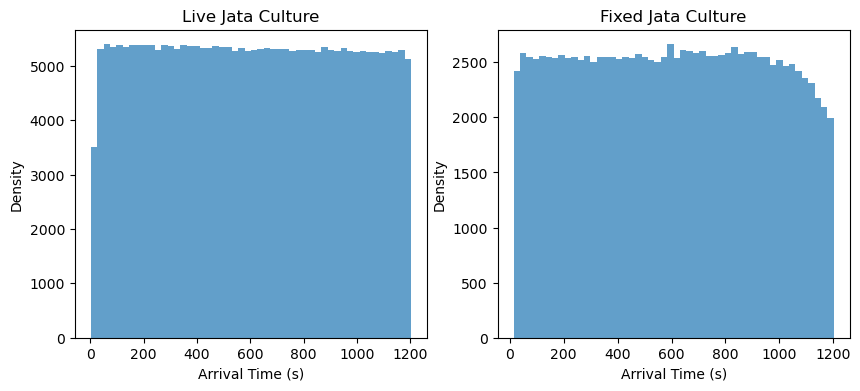

In [50]:
fig , ax = plt.subplots(1,2,figsize=(10, 4))

ax[0].hist(jatalive_df['RunTime'], bins=50, alpha=0.7)
ax[0].set_xlabel('Arrival Time (s)')
ax[0].set_ylabel('Density')
ax[0].set_title('Live Jata Culture')

ax[1].hist(jatafixed_df['RunTime'], bins=50, alpha=0.7)
ax[1].set_xlabel('Arrival Time (s)')
ax[1].set_ylabel('Density')
ax[1].set_title('Fixed Jata Culture')

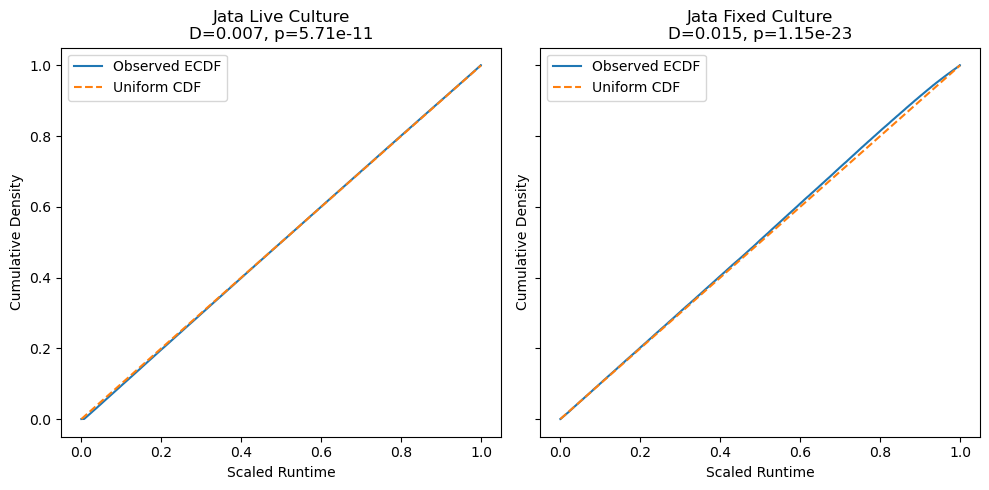

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5),
                         sharex=True, sharey=True)




plot_multi_runtime_cdf(jatalive_df, axes[0], "Jata Live Culture")
plot_multi_runtime_cdf(jatafixed_df, axes[1], "Jata Fixed Culture")

# fig.supxlabel("Scaled Runtime", fontsize=14)
# fig.supylabel("Cumulative Density", fontsize=14)

plt.tight_layout()
plt.show()

## Alex Culture 

In [21]:
alexlive_df = combine_csvs_with_filename("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/dilExp/Alex/hablab_AlexHighV/merged")
alexfixed_df = combine_csvs_with_filename("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/fixed/alexFixed/FixedAlex/merged/")

Text(0.02, 0.5, ' Density')

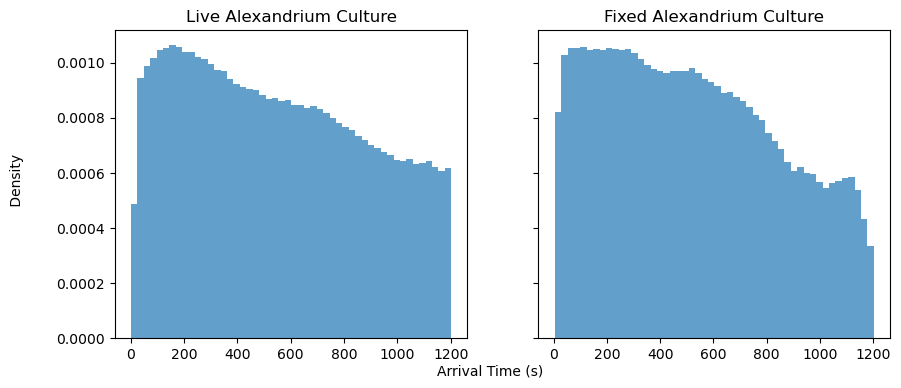

In [25]:
fig , ax = plt.subplots(1,2,figsize=(10, 4), sharex=True, sharey=True)

ax[0].hist(alexlive_df['RunTime'], bins=50, alpha=0.7 , density=True)
# ax[0].set_xlabel('Arrival Time (s)')
# ax[0].set_ylabel('Density')
ax[0].set_title('Live Alexandrium Culture')

ax[1].hist(alexfixed_df['RunTime'], bins=50, alpha=0.7, density=True)
# ax[1].set_xlabel('Arrival Time (s)')
# ax[1].set_ylabel('Density')
ax[1].set_title('Fixed Alexandrium Culture')

fig.supxlabel("Arrival Time (s)", fontsize=10)
fig.supylabel(" Density", fontsize=10)

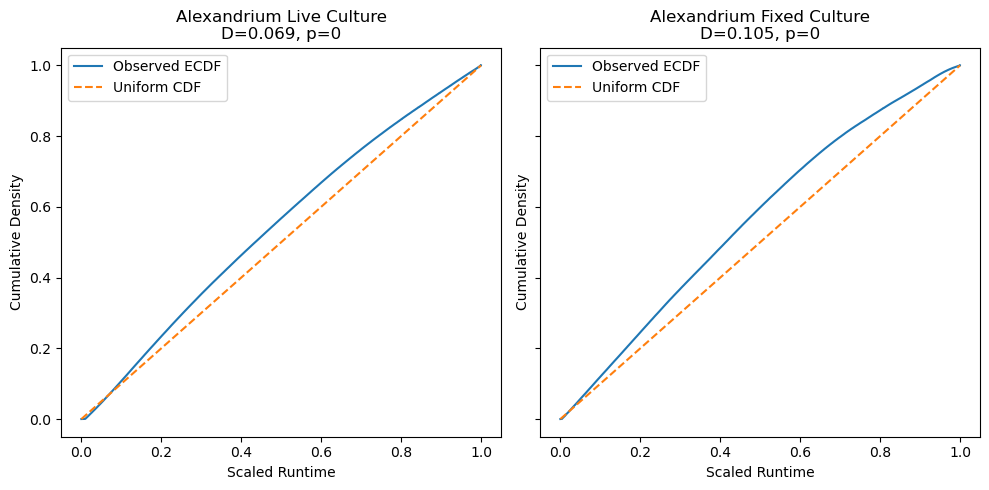

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5),
                         sharex=True, sharey=True)




plot_multi_runtime_cdf(alexlive_df, axes[0], "Alexandrium Live Culture")
plot_multi_runtime_cdf(alexfixed_df, axes[1], "Alexandrium Fixed Culture")

# fig.supxlabel("Scaled Runtime", fontsize=14)
# fig.supylabel("Cumulative Density", fontsize=14)

plt.tight_layout()
plt.show()

## Beads

In [45]:
beads_df = combine_csvs_with_filename("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/dilExp/beadsExp/hablab_beadsExp/merged/IFCB149")

Text(0.5, 1.0, 'Beads ')

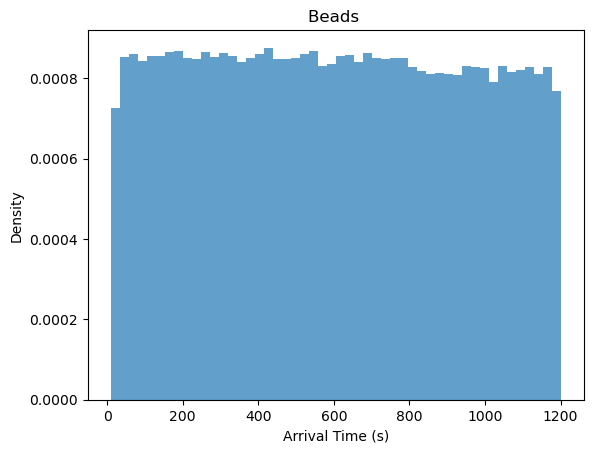

In [29]:
plt.hist(beads_df['RunTime'], bins=50, alpha=0.7, density=True)
plt.xlabel('Arrival Time (s)')
plt.ylabel('Density')
plt.title('Beads ')

KS statistic: 0.009
p-value: 4.18e-14


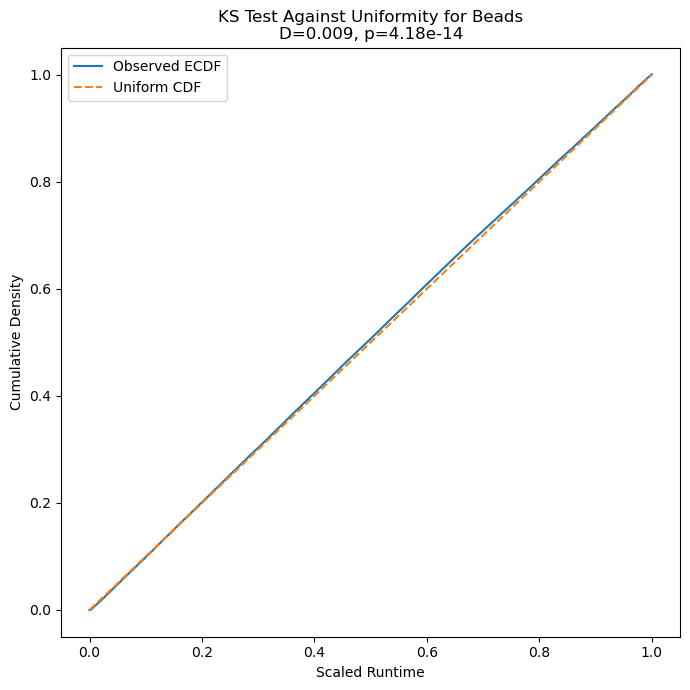

In [36]:
beads_K, beads_p = plot_single_runtime_cdf(beads_df, "KS Test Against Uniformity for Beads")

## Concentration Comparisons

In [37]:
import pandas as pd


def calculate_concentrations(df):
    particle_counts = {}
    volumes = {}
    concentrations = {}

    for file in df["FileName"].unique():
        file_df = df[df["FileName"] == file]

        # Exclude RoiType == 0
        file_df = file_df[file_df["RoiType"] != 0]

        total_particles = len(file_df)
        total_volume = file_df["VolumeAnalyzed"].max()

        particle_counts[file] = total_particles
        volumes[file] = total_volume

        if pd.notna(total_volume) and total_volume > 0:
            concentrations[file] = total_particles / total_volume
        else:
            concentrations[file] = 0

    concentration_df = pd.DataFrame({
        "FileName": list(particle_counts.keys()),
        "ParticleCount": list(particle_counts.values()),
        "VolumeAnalyzed": list(volumes.values()),
        "Concentration": list(concentrations.values())
    })

    return concentration_df

In [48]:
jatalive_df.columns.tolist

<bound method IndexOpsMixin.tolist of Index(['RoiNumber', 'ADCtime', 'RunTime', 'InhibitTime', 'InhibitTimeDiff',
       'VolumeAnalyzed', 'IsZeroRoi', 'RoiHeight', 'RoiWidth', 'RoiX', 'RoiY',
       'FileName'],
      dtype='object')>

In [55]:
dfs = {
    "Jata Live": jatalive_df,
    "Jata Fixed": jatafixed_df,
    "Alexandrium Live": alexlive_df,
    "Alexandrium Fixed": alexfixed_df,
    "Beads": beads_df
}

results = []

for culture_type, df in dfs.items():
    temp_df = calculate_concentrations(df)
    temp_df["CultureType"] = culture_type
    results.append(temp_df)

concentration_df = pd.concat(results, ignore_index=True)

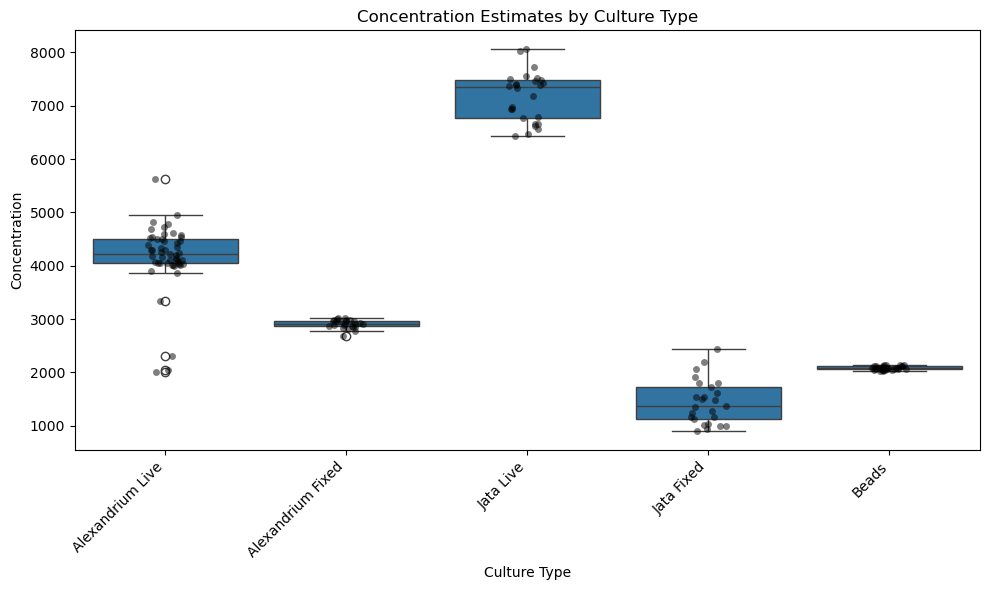

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort culture types alphabetically
culture_order = [
    "Alexandrium Live",
    "Alexandrium Fixed",
    "Jata Live",
    "Jata Fixed",
    "Beads"
]

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=concentration_df,
    x="CultureType",
    y="Concentration",
    order=culture_order
)

sns.stripplot(
    data=concentration_df,
    x="CultureType",
    y="Concentration",
    order=culture_order,
    color="black",
    alpha=0.5,
    jitter=True
)

plt.xlabel("Culture Type")
plt.ylabel("Concentration")
plt.title("Concentration Estimates by Culture Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [60]:
microscopy_df = pd.read_csv("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/misc/ResearchReportCellCounts_test.csv", ignore_index=True)

TypeError: read_csv() got an unexpected keyword argument 'ignore_index'

In [62]:
treatments = microscopy_df["Treatment"].unique()
print(treatments)

['Alex Live' 'Jata Live' 'Jata Live Recount' 'Beads' 'Alex Fixed']


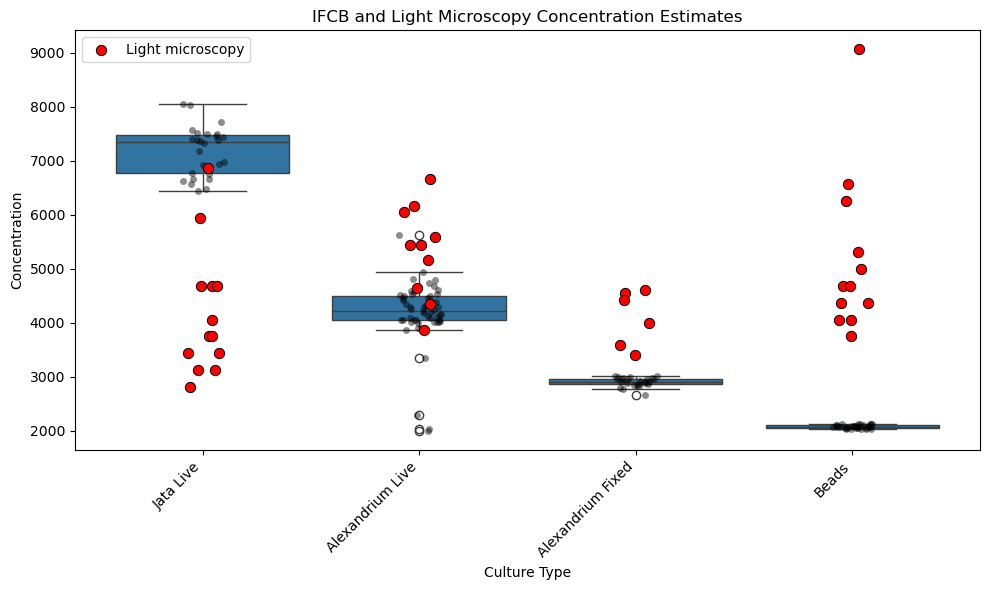

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Map microscopy treatment names to concentration_df CultureType names
treatment_map = {
    "Alex Live": "Alexandrium Live",
    "Alex Fixed": "Alexandrium Fixed",
    "Jata Live": "Jata Live",
    "Jata Live Recount": "Jata Live",
    "Beads": "Beads"
}

microscopy_plot = microscopy_df.copy()

microscopy_plot["CultureType"] = microscopy_plot["Treatment"].map(treatment_map)

# Keep rows with a valid treatment and comparable concentration
microscopy_plot = microscopy_plot.dropna(
    subset=["CultureType", "Comparable Concentration (Conc * dilution factor)"]
)

# Desired ordering
culture_order = [
    "Jata Live",
    "Alexandrium Live",
    "Alexandrium Fixed",
    "Beads"
]

fig, ax = plt.subplots(figsize=(10, 6))

# IFCB distributions
sns.boxplot(
    data=concentration_df,
    x="CultureType",
    y="Concentration",
    order=culture_order,
    ax=ax
)

# Optional: show individual IFCB measurements
sns.stripplot(
    data=concentration_df,
    x="CultureType",
    y="Concentration",
    order=culture_order,
    color="black",
    alpha=0.45,
    jitter=True,
    ax=ax
)

# Overlay microscopy values as red dots
rng = np.random.default_rng(42)

for i, culture in enumerate(culture_order):
    values = microscopy_plot.loc[
        microscopy_plot["CultureType"] == culture,
        "Comparable Concentration (Conc * dilution factor)"
    ].to_numpy()

    # Small horizontal jitter so overlapping points remain visible
    x_positions = i + rng.uniform(-0.08, 0.08, size=len(values))

    ax.scatter(
        x_positions,
        values,
        color="red",
        edgecolor="black",
        linewidth=0.7,
        s=55,
        zorder=5,
        label="Light microscopy" if i == 0 else None
    )

ax.set_xlabel("Culture Type")
ax.set_ylabel("Concentration")
ax.set_title("IFCB and Light Microscopy Concentration Estimates")
ax.legend()

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

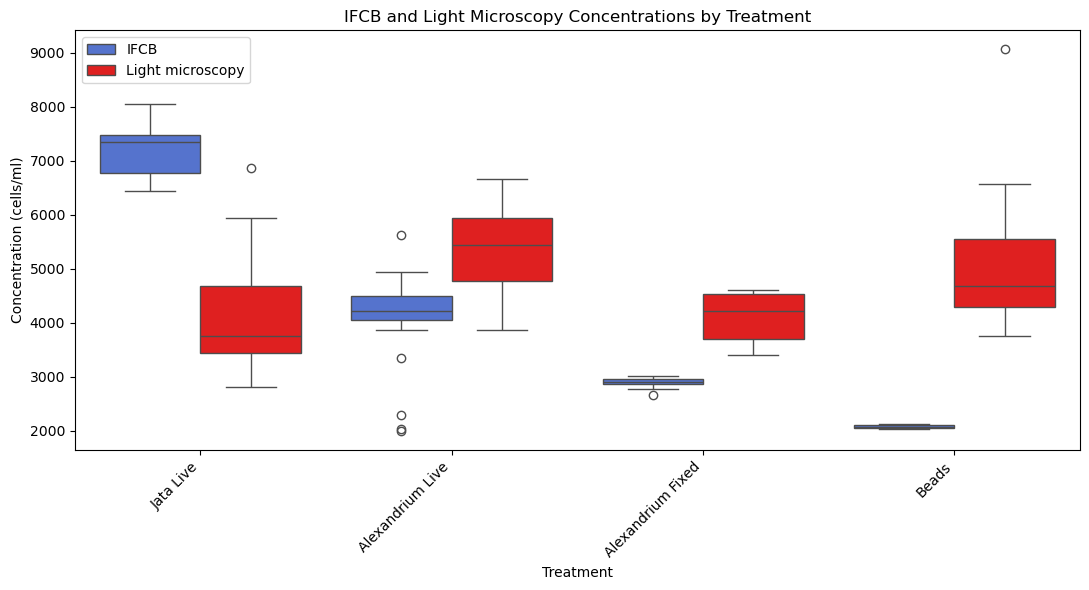

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Map microscopy treatment names to CultureType names
treatment_map = {
    "Alex Live": "Alexandrium Live",
    "Alex Fixed": "Alexandrium Fixed",
    "Jata Live": "Jata Live",
    "Jata Live Recount": "Jata Live",
    "Beads": "Beads"
}

# IFCB data
ifcb_plot = concentration_df[
    ["CultureType", "Concentration"]
].copy()

ifcb_plot = ifcb_plot.rename(
    columns={"Concentration": "Value"}
)

ifcb_plot["DataType"] = "IFCB"

# Microscopy data
microscopy_plot = microscopy_df.copy()
microscopy_plot["CultureType"] = microscopy_plot["Treatment"].map(treatment_map)

microscopy_plot = microscopy_plot.rename(
    columns={
        "Comparable Concentration (Conc * dilution factor)": "Value"
    }
)

microscopy_plot = microscopy_plot[
    ["CultureType", "Value"]
].copy()

microscopy_plot["DataType"] = "Light microscopy"

# Combine both datasets
combined_plot = pd.concat(
    [ifcb_plot, microscopy_plot],
    ignore_index=True
).dropna(subset=["CultureType", "Value"])

# Desired treatment order
culture_order = [
    "Jata Live",
    "Alexandrium Live",
    "Alexandrium Fixed",
    "Beads"
]

# Side-by-side boxplots
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=combined_plot,
    x="CultureType",
    y="Value",
    hue="DataType",
    order=culture_order,
    hue_order=["IFCB", "Light microscopy"],
    palette={
        "IFCB": "royalblue",
        "Light microscopy": "red"
    }
)

plt.xlabel("Treatment")
plt.ylabel("Concentration (cells/ml)")
plt.title("IFCB and Light Microscopy Concentrations by Treatment")
plt.xticks(rotation=45, ha="right")
plt.legend(title="")
plt.tight_layout()
plt.show()